# NPU/GPU MatMul Profiling

In [18]:
result_path = "./mm.csv"
result_path2 = "./mm_power.csv"

def parse_result1(result_path):
    results = {}
    with open(result_path, "r") as f:
        lines = f.readlines()
        for line in lines:
            items = [item.strip() for item in line.split(",")]
            assert len(items) == 10
            shape_key = (int(items[0]), int(items[1]), int(items[2]))
            results[shape_key] = (float(items[3]), #AI
                                  int(items[4]), #GPU compile time
                                  int(items[5]), #NPU compile time
                                  int(items[6]), #GPU runtime (us)
                                  int(items[7]), #NPU runtime (us)
                                  float(items[8]), #GPU throughput
                                  float(items[9])) #NPU throughput
    return results
results1 = parse_result1(result_path)

def parse_result2(result_path):
    results = {}
    with open(result_path, "r") as f:
        lines = f.readlines()
        for line in lines:
            items = [item.strip() for item in line.split(",")]
            assert len(items) == 5
            shape_key = (int(items[0]), int(items[1]), int(items[2]))
            results[shape_key] = (float(items[3]), #GPU Power
                                  float(items[4])) #NPU Power
    return results
results2 = parse_result2(result_path2)

# (k, 4096, 4096)
keys1 = [(1, 4096, 4096)] + [(i, 4096, 4096) for i in range(8, 4097, 8)]
data1 = [results1[key] for key in keys1]

# (k, 4096, 11008)
keys2 = [(1, 4096, 11008)] + [(i, 4096, 11008) for i in range(8, 4097, 8)]
data2 = [results1[key] for key in keys2]

# (k, 4096, 4096)
keys3 = [(100 * 2**i, 4096, 4096) for i in range(6)] + [(4096, 4096, 4096)]
data3 = [results2[key] for key in keys3]
data3_1 = [results1[key] for key in keys3]

# (k, 4096, 11008)
keys4 = [(100 * 2**i, 4096, 11008) for i in range(6)] + [(4096, 4096, 11008)]
data4 = [results2[key] for key in keys4]
data4_1 = [results1[key] for key in keys4]

## Compile time
### [k, 4096] * [4096, 4096] and [4096, 4096] * [4096, k]

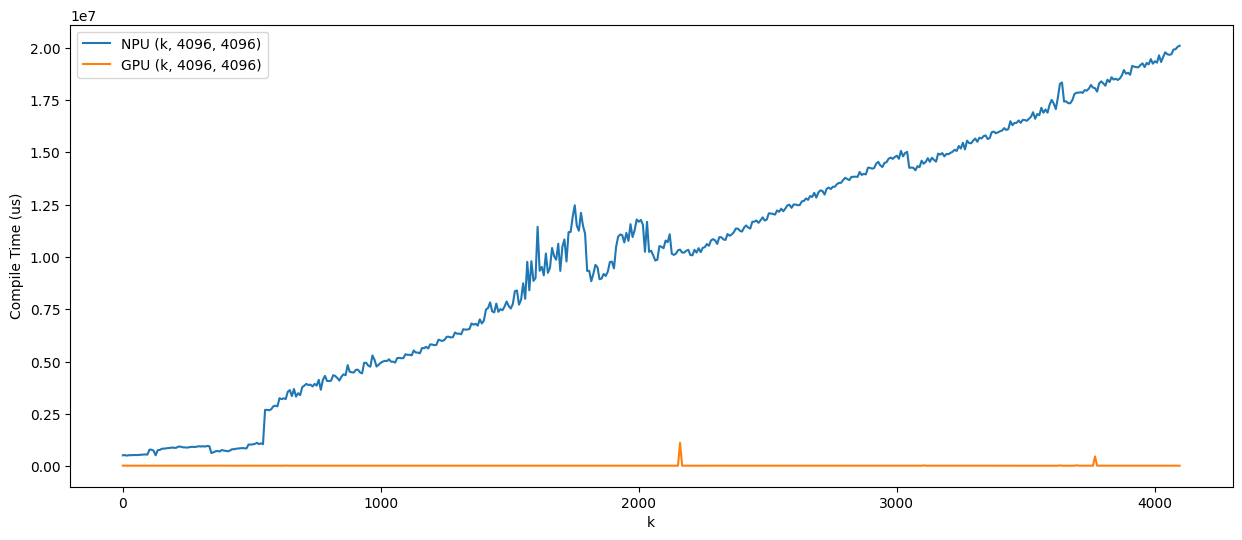

In [10]:
import matplotlib.pyplot as plt
import numpy as np    

x = [k[0] for k in keys1]
gpu_y1 = [d[1] for d in data1]
npu_y1 = [d[2] for d in data1]

# plot a line chart with common x and four lines with each y data
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, npu_y1, label='NPU (k, 4096, 4096)')
ax.plot(x, gpu_y1, label='GPU (k, 4096, 4096)')

ax.set_xlabel('k')
ax.set_ylabel('Compile Time (us)')
ax.legend()
plt.show()

### [k, 4096] * [4096, 11008] and [11008, 4096] * [4096, k]

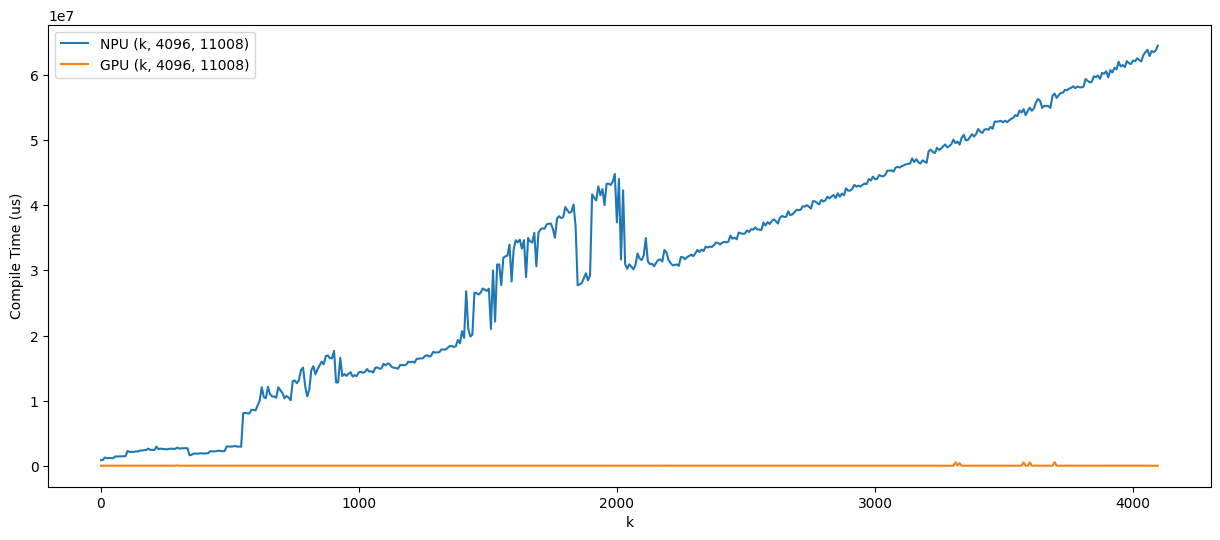

In [ ]:
x = [k[0] for k in keys2]
gpu_y1 = [d[1] for d in data2]
npu_y1 = [d[2] for d in data2]

# plot a line chart with common x and four lines with each y data
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, gpu_y1, label='GPU (k, 4096, 11008)')
ax.plot(x, npu_y1, label='NPU (k, 4096, 11008)')

ax.set_xlabel('k')
ax.set_ylabel('Compile Time (us)')
ax.legend()
plt.show()

## Runtime
### [k, 4096] * [4096, 4096] and [4096, 4096] * [4096, k]

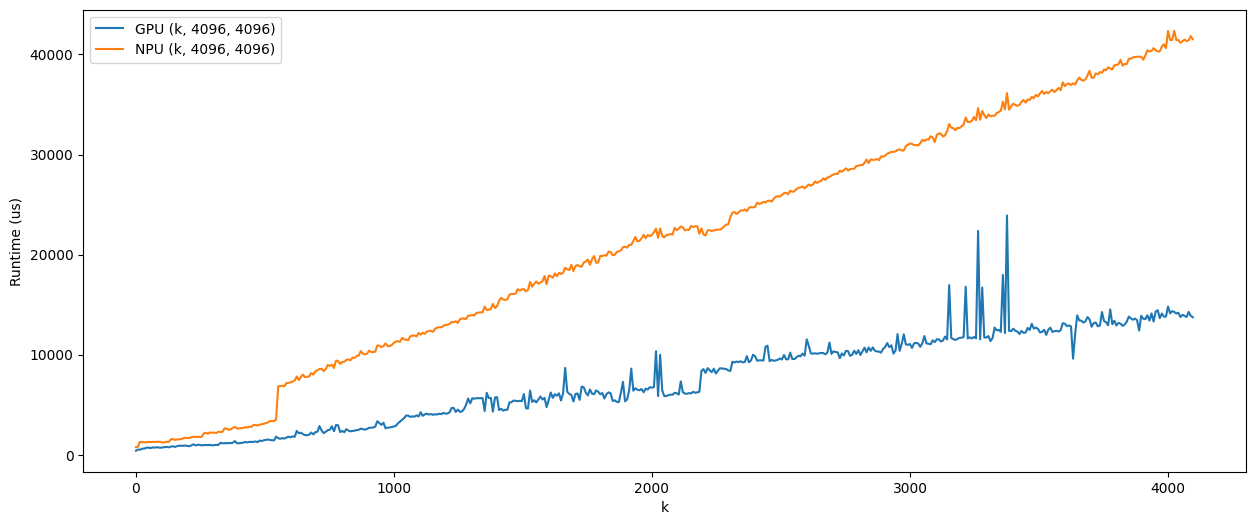

In [11]:
x = [k[0] for k in keys1]
gpu_y2 = [d[3] for d in data1]
npu_y2 = [d[4] for d in data1]

# plot a line chart with common x and four lines with each y data
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, gpu_y2, label='GPU (k, 4096, 4096)')
ax.plot(x, npu_y2, label='NPU (k, 4096, 4096)')
ax.set_xlabel('k')
ax.set_ylabel('Runtime (us)')
ax.legend()
plt.show()

### [k, 4096] * [4096, 11008] and [11008, 4096] * [4096, k]

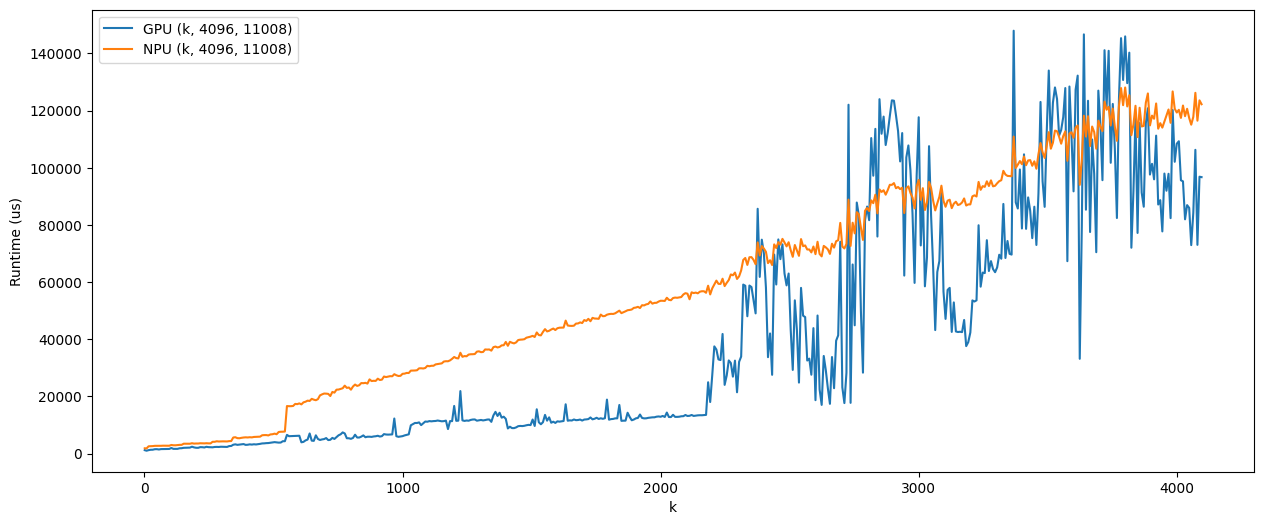

In [22]:
x = [k[0] for k in keys2]
gpu_y2 = [d[3] for d in data2]
npu_y2 = [d[4] for d in data2]

# plot a line chart with common x and four lines with each y data
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, gpu_y2, label='GPU (k, 4096, 11008)')
ax.plot(x, npu_y2, label='NPU (k, 4096, 11008)')
ax.set_xlabel('k')
ax.set_ylabel('Runtime (us)')
ax.legend()
plt.show()

## Throughput (TOPS)
### [k, 4096] * [4096, 4096] and [4096, 4096] * [4096, k]

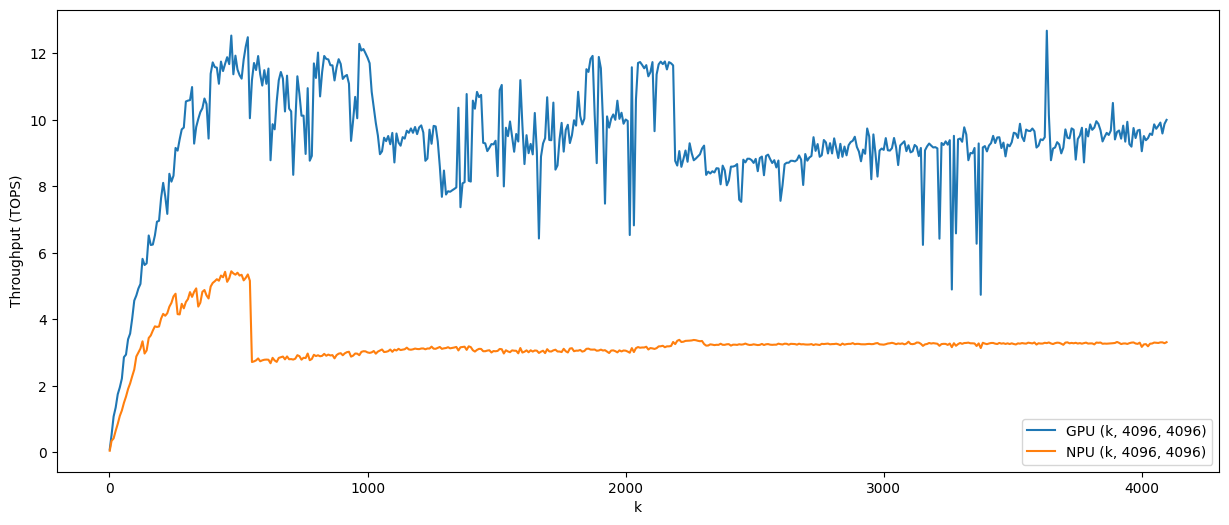

In [12]:
x = [k[0] for k in keys1]
gpu_y3 = [d[5] for d in data1]
npu_y3 = [d[6] for d in data1]

# plot a line chart with common x and four lines with each y data
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, gpu_y3, label='GPU (k, 4096, 4096)')
ax.plot(x, npu_y3, label='NPU (k, 4096, 4096)')
ax.set_xlabel('k')
ax.set_ylabel('Throughput (TOPS)')
ax.legend()
plt.show()

### [k, 4096] * [4096, 11008] and [11008, 4096] * [4096, k]

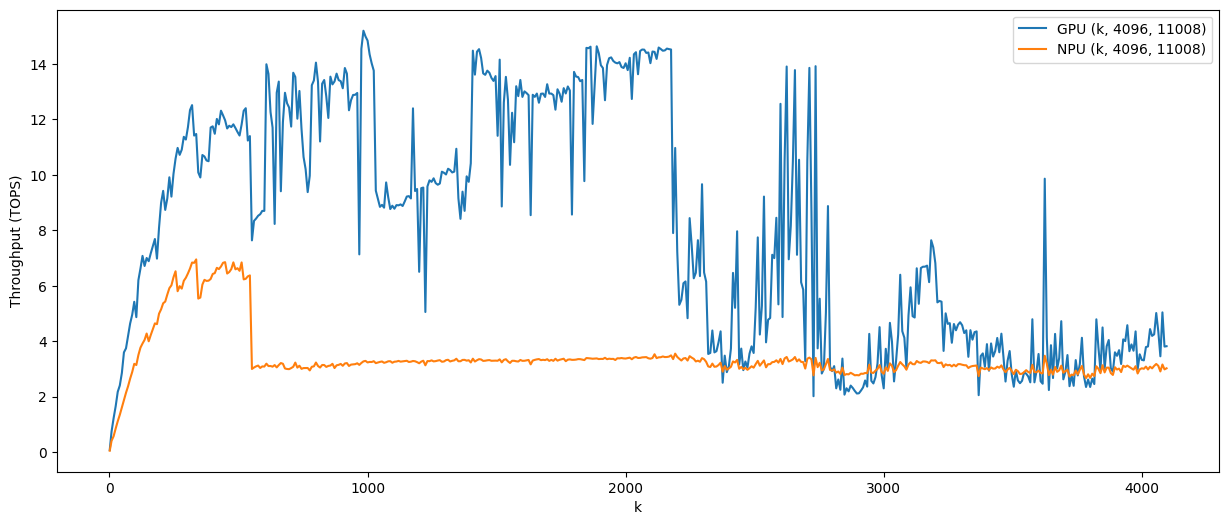

In [24]:
x = [k[0] for k in keys2]
gpu_y3 = [d[5] for d in data2]
npu_y3 = [d[6] for d in data2]

# plot a line chart with common x and four lines with each y data
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, gpu_y3, label='GPU (k, 4096, 11008)')
ax.plot(x, npu_y3, label='NPU (k, 4096, 11008)')
ax.set_xlabel('k')
ax.set_ylabel('Throughput (TOPS)')
ax.legend()
plt.show()


## Power (mW)
### [k, 4096] * [4096, 4096] and [4096, 4096] * [4096, k]

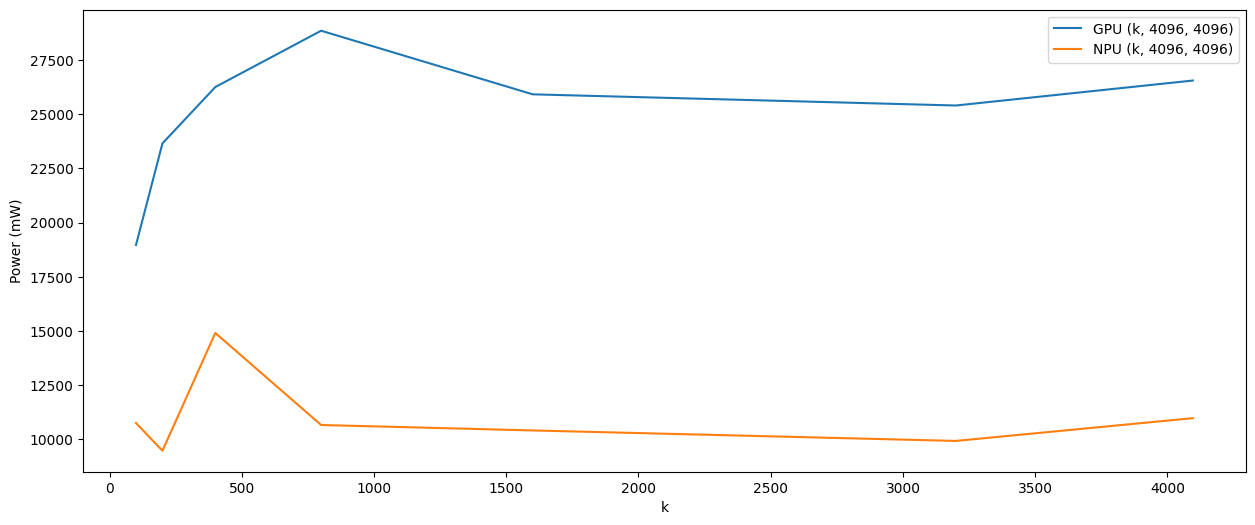

In [14]:
x = [k[0] for k in keys3]
gpu_y4 = [d[0] for d in data3]
npu_y4 = [d[1] for d in data3]

# plot a line chart with common x and four lines with each y data
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, gpu_y4, label='GPU (k, 4096, 4096)')
ax.plot(x, npu_y4, label='NPU (k, 4096, 4096)')
ax.set_xlabel('k')
ax.set_ylabel('Power (mW)')
ax.legend()
plt.show()

### [k, 4096] * [4096, 11008] and [11008, 4096] * [4096, k]

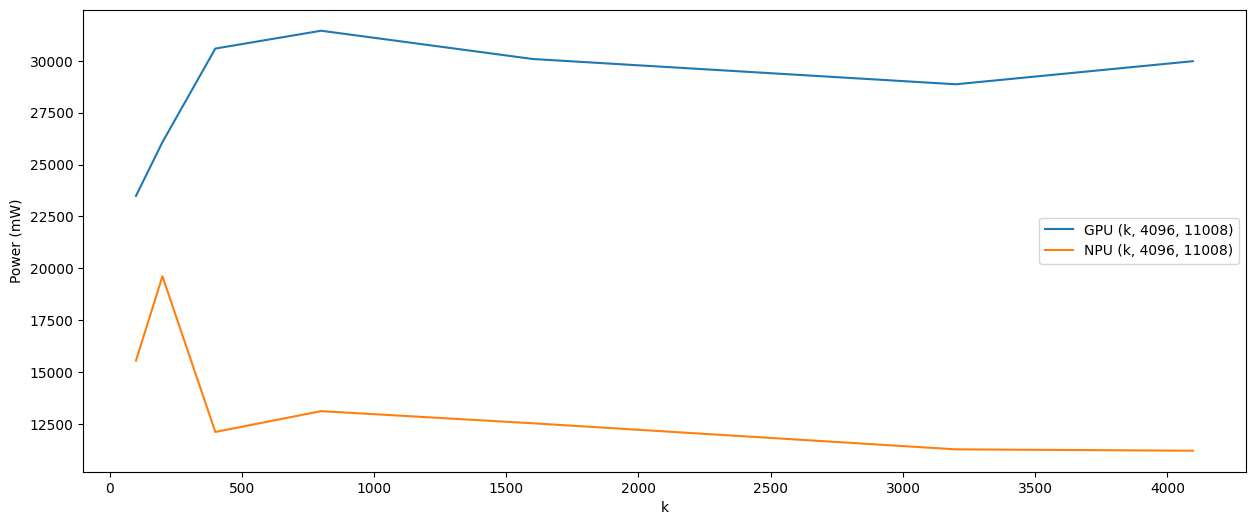

In [15]:
x = [k[0] for k in keys4]
gpu_y4 = [d[0] for d in data4]
npu_y4 = [d[1] for d in data4]

# plot a line chart with common x and four lines with each y data
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, gpu_y4, label='GPU (k, 4096, 11008)')
ax.plot(x, npu_y4, label='NPU (k, 4096, 11008)')
ax.set_xlabel('k')
ax.set_ylabel('Power (mW)')
ax.legend()
plt.show()

## Energy Efficiency (TOPS/mW)
### [k, 4096] * [4096, 4096] and [4096, 4096] * [4096, k]

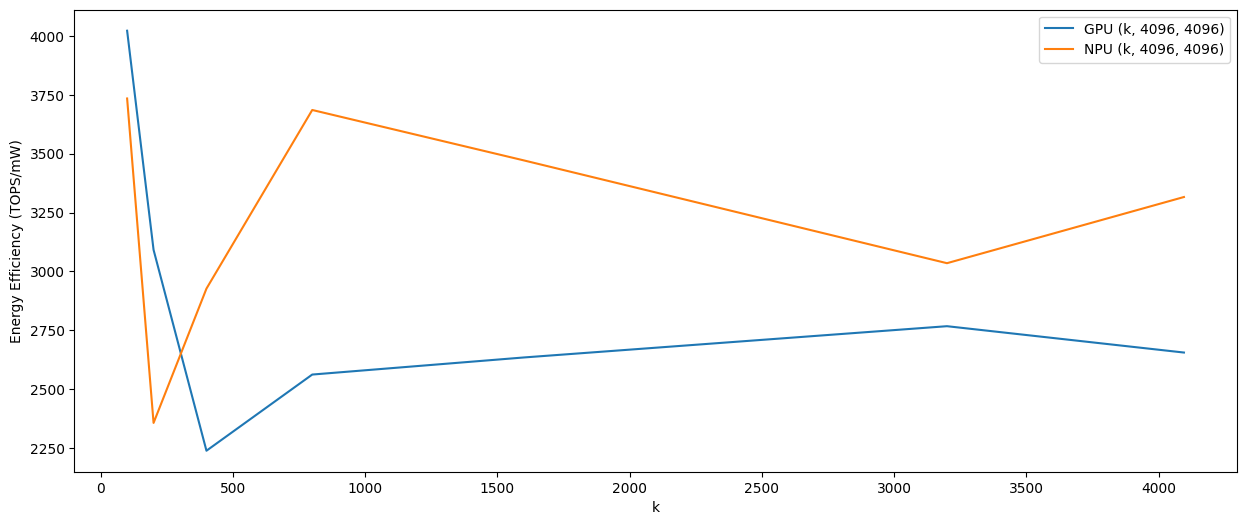

In [19]:
x = [k[0] for k in keys3]

gpu_y4 = [d[0] for d in data3]
npu_y4 = [d[1] for d in data3]
gpu_y4_1 = [d[5] for d in data3_1]
npu_y4_1 = [d[6] for d in data3_1]
gpu_y4 = [gpu_y4[i] / gpu_y4_1[i] for i in range(len(gpu_y4))]
npu_y4 = [npu_y4[i] / npu_y4_1[i] for i in range(len(npu_y4))]

# plot a line chart with common x and four lines with each y data
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, gpu_y4, label='GPU (k, 4096, 4096)')
ax.plot(x, npu_y4, label='NPU (k, 4096, 4096)')
ax.set_xlabel('k')
ax.set_ylabel('Energy Efficiency (TOPS/mW)')
ax.legend()
plt.show()